In [1]:
import numpy as np
import pandas as pd
from datasets import load_dataset
import gensim.downloader as api

from task6.utils.balance_dataset import augment_minority_classes
from task6.utils.prepare_data import prepare_data

C:\Projects\BUAS\Y2\block-a\fae2-nlpr-group-group-9-1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Szymon\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [2]:
dataset = load_dataset("google-research-datasets/go_emotions")
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5427
    })
})

In [3]:
df = pd.DataFrame(dataset["train"])
df.head()

,text,labels,id
0,My favourite food is anything I didn't have to...,[27],eebbqej
1,"Now if he does off himself, everyone will thin...",[27],ed00q6i
2,WHY THE FUCK IS BAYLESS ISOING,[2],eezlygj
3,To make her feel threatened,[14],ed7ypvh
4,Dirty Southern Wankers,[3],ed0bdzj


In [4]:
df, emotions = prepare_data(df, "text", "labels")
print(emotions)
df.head()

Detected dataset type: goemotions
Starting batch preprocessing...
✓ Text cleaning completed
✓ All NLP processing completed
['anger', 'disgust', 'fear', 'joy', 'sadness', 'surprise', 'neutral']


,text,id,ekman_emotion,tokenized_text,lemmatized_text
0,My favourite food is anything I didn't have to...,eebbqej,6,"[my, favourite, food, is, anything, i, did, n'...","[my, favourite, food, be, anything, I, do, not..."
1,"Now if he does off himself, everyone will thin...",ed00q6i,6,"[now, if, he, does, off, himself, ,, everyone,...","[now, if, he, do, off, himself, ,, everyone, w..."
2,WHY THE FUCK IS BAYLESS ISOING,eezlygj,0,"[why, the, fuck, is, bayless, isoing]","[why, the, fuck, be, bayless, isoe]"
3,To make her feel threatened,ed7ypvh,2,"[to, make, her, feel, threatened]","[to, make, she, feel, threaten]"
4,Dirty Southern Wankers,ed0bdzj,0,"[dirty, southern, wankers]","[dirty, southern, wanker]"


In [5]:
df_test = pd.read_csv("../../data/kinga.csv")
df_test, emotions_test = prepare_data(df_test, "Translation", "Emotion_core")

Detected dataset type: transcript
Starting batch preprocessing...
✓ Text cleaning completed
✓ All NLP processing completed


In [6]:
target_samples = 2500

classes_to_augment = df["ekman_emotion"].value_counts()[df["ekman_emotion"].value_counts() < target_samples].index.tolist()
print(f"Classes to augment: {classes_to_augment}")

Classes to augment: [2, 1]


In [7]:
df_augmented = augment_minority_classes(df, target_samples=target_samples, classes_to_augment=classes_to_augment)
df_augmented = pd.concat([df, df_augmented]).reset_index(drop=True)
print(df_augmented["ekman_emotion"].value_counts())
print(f"Original size: {len(df)}, Augmented size: {len(df_augmented)}")
df = df_augmented

Augmenting emotion 2: 691 → 2500
Augmenting emotion 1: 638 → 2500
Augmented Sample 1: see people overtake on the make I anxious .
Augmented Sample 2: I have this too , so do not worry . we be not crazy . just regular human who happen to have an anxiety issue .
Augmented Sample 3: those spike ear ... those horrible ear
ekman_emotion
3    16920
6    12823
0     5579
5     4160
4     2599
2     2500
1     2500
Name: count, dtype: int64
Original size: 43410, Augmented size: 47081


In [8]:
df["lemmatized_text"] = df["lemmatized_text"].apply(lambda tokens: " ".join(tokens))
df_test["lemmatized_text"] = df_test["lemmatized_text"].apply(lambda tokens: " ".join(tokens))

In [9]:
embedding_model = api.load("glove-twitter-100")

In [10]:
# create a function to compute the mean word2vec vector for a given text
def compute_mean_word2vec(text, model, vector_size=100):
    words = text.split()
    word_vectors = []
    for word in words:
        if word in model:
            word_vectors.append(model[word])
    if word_vectors:
        return np.mean(word_vectors, axis=0)
    else:
        return np.zeros(vector_size)

In [11]:
df["word2vec"] = df["lemmatized_text"].apply(lambda x: compute_mean_word2vec(x, embedding_model))
df_test["word2vec"] = df_test["lemmatized_text"].apply(lambda x: compute_mean_word2vec(x, embedding_model))

In [12]:
from transformers import pipeline

# sentiment analysis
sentiment = pipeline("sentiment-analysis", model="cardiffnlp/twitter-xlm-roberta-base-sentiment", top_k=None)

Device set to use cuda:0


In [13]:
def analyze_sentiment_batch(texts, max_len=500):
    # Trim all texts upfront
    trimmed_texts = [
        t[:max_len] if isinstance(t, str) and len(t) > max_len else t
        for t in texts
    ]

    # Run through the pipeline in batches
    results = sentiment(trimmed_texts, batch_size=256)

    numeric_scores = []
    for result in results:
        best = max(result, key=lambda x: x["score"])
        label = best["label"]
        conf = best["score"]

        if label == "negative":
            numeric_scores.append(-conf)
        elif label == "neutral":
            numeric_scores.append(0.0)
        elif label == "positive":
            numeric_scores.append(conf)
        else:
            numeric_scores.append(0.0)

    return numeric_scores

In [14]:
df["sentiment_score"] = analyze_sentiment_batch(df["lemmatized_text"].tolist())
df_test["sentiment_score"] = analyze_sentiment_batch(df_test["lemmatized_text"].tolist())

In [15]:
# Intensity markers count: occurrences of "very", "so", "extremely" and other similar words
intensity_markers = ["very", "so", "extremely", "highly", "too", "really", "absolutely", "completely", "totally", "utterly"]
df["intensity_marker_count"] = df["lemmatized_text"].apply(lambda x: sum(x.lower().count(marker) for marker in intensity_markers))
df_test["intensity_marker_count"] = df_test["lemmatized_text"].apply(lambda x: sum(x.lower().count(marker) for marker in intensity_markers))

In [16]:
# load emotion lexicon
emotion_lexicon = pd.read_csv("../../data/NRC-Emotion-Lexicon-Wordlevel-v0.92.txt", sep="\t", names=["word", "emotion", "association"])
# pivot the lexicon to have emotions as columns
emotion_lexicon_pivot = emotion_lexicon.pivot(index="word", columns="emotion", values="association").fillna(0)
# create a dictionary for faster lookup
emotion_dict = emotion_lexicon_pivot.to_dict(orient="index")

In [17]:
def return_emotion_counts(lemmas_str):
    lemmas = lemmas_str.lower().split()
    counts = {emotion: 0 for emotion in emotion_lexicon_pivot.columns}

    for lemma in lemmas:
        if lemma in emotion_dict:
            for emotion in emotion_dict[lemma]:
                # increment only emotions marked 1
                if emotion_dict[lemma][emotion] == 1:
                    counts[emotion] += 1

    return pd.Series(counts)

In [18]:
emotion_counts = df["lemmatized_text"].apply(return_emotion_counts)
df = pd.concat([df, emotion_counts], axis=1)

In [19]:
emotion_counts = df_test["lemmatized_text"].apply(return_emotion_counts)
df_test = pd.concat([df_test, emotion_counts], axis=1)

In [20]:
# calculate number of tokens, ratio of unique tokens to total tokens, average word length
df["num_tokens"] = df["lemmatized_text"].apply(lambda x: len(x.split()))
df["unique_token_ratio"] = df["lemmatized_text"].apply(lambda x: len(set(x.split())) / len(x.split()) if len(x.split()) > 0 else 0)
df["avg_word_length"] = df["lemmatized_text"].apply(lambda x: np.mean([len(word) for word in x.split()]) if len(x.split()) > 0 else 0)
df_test["num_tokens"] = df_test["lemmatized_text"].apply(lambda x: len(x.split()))
df_test["unique_token_ratio"] = df_test["lemmatized_text"].apply(lambda x: len(set(x.split())) / len(x.split()) if len(x.split()) > 0 else 0)
df_test["avg_word_length"] = df_test["lemmatized_text"].apply(lambda x: np.mean([len(word) for word in x.split()]) if len(x.split()) > 0 else 0)

In [21]:
# calculate punctuation count
import string
df["punctuation_count"] = df["lemmatized_text"].apply(lambda x: sum([1 for char in x if char in string.punctuation]))
df_test["punctuation_count"] = df_test["lemmatized_text"].apply(lambda x: sum([1 for char in x if char in string.punctuation]))

In [22]:
# Negation feature: binary if any negation word in window of previous 3 tokens
negation_words = set(["not", "no", "never", "n't", "none", "nobody", "nothing", "neither", "nowhere", "hardly", "scarcely", "barely", "doesn't", "isn't", "wasn't", "shouldn't", "wouldn't", "couldn't", "won't", "can't", "don't"])
def negation_feature(text):
    tokens = text.split()
    return 1 if any(token in negation_words for token in tokens) else 0
df["negation"] = df["lemmatized_text"].apply(negation_feature)
df_test["negation"] = df_test["lemmatized_text"].apply(negation_feature)

In [23]:
from sklearn.preprocessing import StandardScaler
additional_features = df[["sentiment_score", "intensity_marker_count", "num_tokens",
                         "unique_token_ratio", "avg_word_length", "punctuation_count",
                         "negation"] + list(emotion_lexicon_pivot.columns)]

scaler = StandardScaler()
additional_features_scaled = scaler.fit_transform(additional_features)
additional_features_test_scaled = scaler.transform(df_test[["sentiment_score", "intensity_marker_count", "num_tokens",
                                                            "unique_token_ratio", "avg_word_length", "punctuation_count",
                                                            "negation"] + list(emotion_lexicon_pivot.columns)])

In [24]:
from scipy.sparse import hstack, csr_matrix

# concat word2vec vectors with additional features
word2vec_features = np.vstack(df["word2vec"].values)
word2vec_features_test = np.vstack(df_test["word2vec"].values)
X_train = hstack([csr_matrix(word2vec_features), csr_matrix(additional_features_scaled)])
X_test = hstack([csr_matrix(word2vec_features_test), csr_matrix(additional_features_test_scaled)])

In [25]:
y_train = df["ekman_emotion"]
y_test = df_test["ekman_emotion"]
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (47081, 117), y_train shape: (47081,)
X_test shape: (791, 117), y_test shape: (791,)


In [26]:
n_samples, n_features = X_train.shape
dual_choice = False if n_samples > n_features else False

In [27]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import RandomizedSearchCV
from sklearn.multiclass import OneVsRestClassifier

In [71]:
param_grid = {
    "estimator__C": [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0],
    "estimator__max_iter": [15000, 20000, 25000, 30000],
    "estimator__class_weight": [None, "balanced"],
    "estimator__loss": ["squared_hinge"],  # Only squared_hinge works with dual=False
    "estimator__penalty": ["l2"]
}

# Also set n_jobs=1 in OneVsRestClassifier to avoid conflicts
randomized_search = RandomizedSearchCV(
    OneVsRestClassifier(LinearSVC(random_state=42, dual=dual_choice), n_jobs=1),
    param_distributions=param_grid,
    cv=3,
    n_jobs=12,
    verbose=2,
    n_iter=50,
    scoring='f1_macro',
    random_state=42,
    return_train_score=True
)

randomized_search.fit(X_train, y_train)

Fitting 3 folds for each of 50 candidates, totalling 150 fits


KeyboardInterrupt: 

KeyboardInterrupt: 

In [34]:
print("\n" + "="*50)
print("RANDOMIZED SEARCH RESULTS")
print("="*50)
print(f"Best parameters: {randomized_search.best_params_}")
print(f"Best CV score: {randomized_search.best_score_:.4f}")
print(f"Best estimator: {randomized_search.best_estimator_}")


RANDOMIZED SEARCH RESULTS
Best parameters: {'estimator__penalty': 'l2', 'estimator__max_iter': 15000, 'estimator__loss': 'squared_hinge', 'estimator__class_weight': 'balanced', 'estimator__C': 2.0}
Best CV score: 0.4619
Best estimator: OneVsRestClassifier(estimator=LinearSVC(C=2.0, class_weight='balanced',
                                        dual=False, max_iter=15000,
                                        random_state=42),
                    n_jobs=1)


In [28]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "estimator__C": [1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0],
    "estimator__max_iter": [12000, 15000, 18000, 20000],
    "estimator__class_weight": ["balanced"],
    "estimator__loss": ["squared_hinge"],
    "estimator__penalty": ["l2"]
}

grid_search = GridSearchCV(
    estimator=OneVsRestClassifier(
    LinearSVC(dual=False, random_state=42),
    n_jobs=1
),
    param_grid=param_grid,
    cv=3,
    scoring='f1_macro',
    n_jobs=12,
    verbose=2
)
print("Starting grid search...")
grid_search.fit(X_train, y_train)
print("\n" + "="*50)
print("GRID SEARCH RESULTS")
print("="*50)
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV score: {grid_search.best_score_:.4f}")
print(f"Best estimator: {grid_search.best_estimator_}")

Starting grid search...
Fitting 3 folds for each of 28 candidates, totalling 84 fits

GRID SEARCH RESULTS
Best parameters: {'estimator__C': 3.0, 'estimator__class_weight': 'balanced', 'estimator__loss': 'squared_hinge', 'estimator__max_iter': 12000, 'estimator__penalty': 'l2'}
Best CV score: 0.4603
Best estimator: OneVsRestClassifier(estimator=LinearSVC(C=3.0, class_weight='balanced',
                                        dual=False, max_iter=12000,
                                        random_state=42),
                    n_jobs=1)


In [29]:
ovr = OneVsRestClassifier(LinearSVC(
    C=grid_search.best_params_["estimator__C"],
    max_iter=grid_search.best_params_["estimator__max_iter"],
    class_weight=grid_search.best_params_["estimator__class_weight"],
    loss=grid_search.best_params_["estimator__loss"],
    penalty=grid_search.best_params_["estimator__penalty"],
    dual=dual_choice,
    random_state=42
), n_jobs=1)
svm_model = ovr.fit(X_train, y_train)

In [30]:
from sklearn.metrics import classification_report
y_pred = svm_model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=emotions_test, zero_division=0, digits=3))

Classification Report:
              precision    recall  f1-score   support

       anger      0.222     0.286     0.250        35
     disgust      0.091     0.111     0.100         9
        fear      0.047     0.086     0.061        58
         joy      0.464     0.556     0.506       153
     sadness      0.483     0.250     0.329        56
    surprise      0.222     0.507     0.309        67
     neutral      0.534     0.341     0.417       413

    accuracy                          0.367       791
   macro avg      0.295     0.305     0.282       791
weighted avg      0.436     0.367     0.382       791



In [31]:
# print random misclassified examples with emotion labels
import random
misclassified_indices = np.where(y_test != y_pred)[0]
random_indices = random.sample(list(misclassified_indices), min(5, len(misclassified_indices)))
for idx in random_indices:
    print(f"Text: {df_test.iloc[idx]['lemmatized_text']}")
    print(f"True label (name): {emotions_test[y_test.iloc[idx]]}, Predicted label (name): {emotions_test[y_pred[idx]]}")
    print("-"*50)

Text: yes .
True label (name): neutral, Predicted label (name): joy
--------------------------------------------------
Text: I be prepared for this moment , for everything .
True label (name): neutral, Predicted label (name): sadness
--------------------------------------------------
Text: do you hear ?
True label (name): neutral, Predicted label (name): surprise
--------------------------------------------------
Text: parsley be so very , you can feel it , and here actually it be less , less , less ,
True label (name): neutral, Predicted label (name): sadness
--------------------------------------------------
Text: music
True label (name): neutral, Predicted label (name): fear
--------------------------------------------------


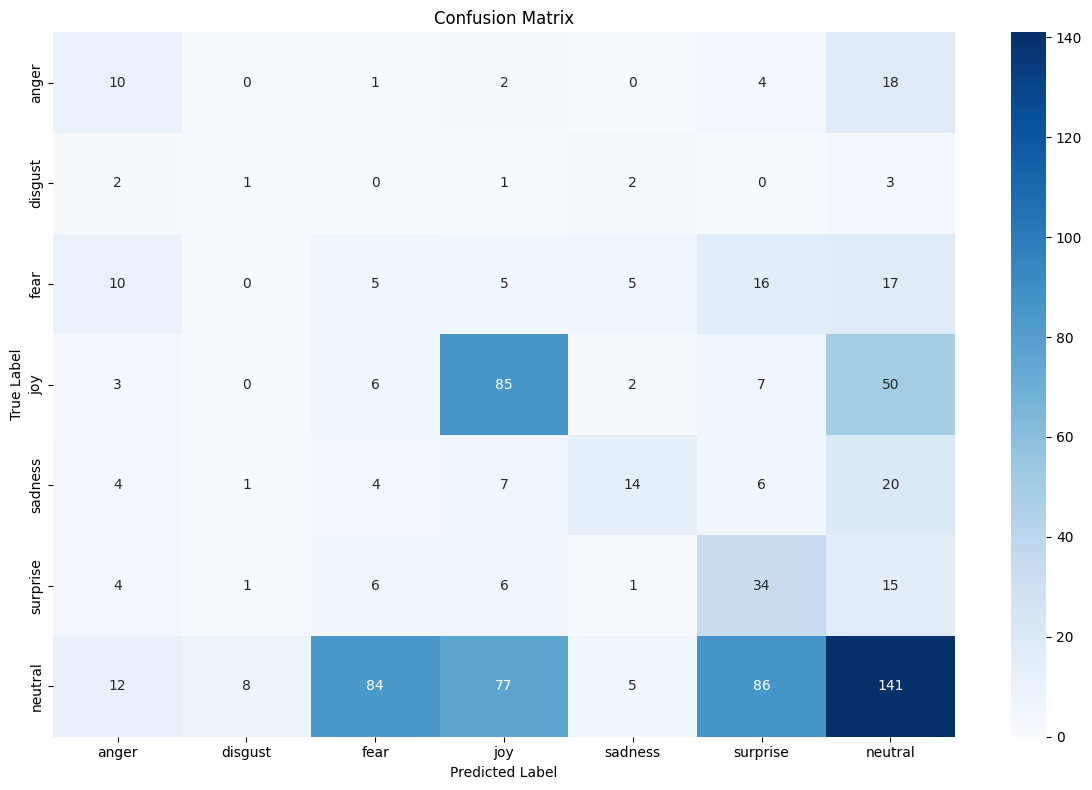

Classification Report:
              precision    recall  f1-score   support

       anger      0.222     0.286     0.250        35
     disgust      0.091     0.111     0.100         9
        fear      0.047     0.086     0.061        58
         joy      0.464     0.556     0.506       153
     sadness      0.483     0.250     0.329        56
    surprise      0.222     0.507     0.309        67
     neutral      0.534     0.341     0.417       413

    accuracy                          0.367       791
   macro avg      0.295     0.305     0.282       791
weighted avg      0.436     0.367     0.382       791


Top 5 Error Patterns: (true → predicted)
------------------------------
neutral → surprise: 86 (17.2% of errors)
neutral → fear: 84 (16.8% of errors)
neutral → joy: 77 (15.4% of errors)
joy → neutral: 50 (10.0% of errors)
sadness → neutral: 20 (4.0% of errors)

Per-Class Performance:
------------------------------
anger        - P: 0.222, R: 0.286, F1: 0.250, Support:  35, Err

In [32]:
from task6.utils.error_analysis import analyze_classification_errors

results = analyze_classification_errors(
    y_true=y_test,
    y_pred=y_pred,
    class_names=emotions_test,
    sample_texts=df_test["lemmatized_text"],
    model=svm_model,
    X_test=X_test,
    top_k_errors=5
)